In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, pointbiserialr
from itertools import combinations

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")

df = pd.read_csv("/home/onyxia/work/bank-full.csv", sep=';')

df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification. Rappelez-vous que, pour éviter le surapprentissage de nos données, nous devons mettre en place une validation croisée, cependant, nous devons nous assurer qu’au moins les fonctionnalités ayant le plus d’influence sur notre étiquette (qu’un client potentiel ouvre un dépôt à terme ou non) soient réparties équitablement. Que veux-je dire par là ?

1) Nous devons voir comment nos données sont distribuées.
2) Après avoir noté que la colonne « prêt » contient 87 % de « non » (Ne pas de prêts personnels) et 13 % de « oui » (Avoir des prêts personnels).
3) Nous voulons nous assurer que notre ensemble d’entraînement et de test contient le même ratio de 87 % de « non » et 13 % de « oui ». Échantillonnage stratifié : C’est un concept important souvent manqué lors du développement d’un modèle, que ce soit pour la régression ou la classification.

Afin de préserver la distribution déséquilibrée de la variable cible, les données ont été séparées en ensembles d’apprentissage et de test à l’aide d’un échantillonnage stratifié basé sur la variable de souscription. Cette approche garantit une représentativité cohérente des classes dans les deux ensembles.

In [11]:
# Echantillonage train-set 

from sklearn.model_selection import StratifiedShuffleSplit

# Définition du split stratifié sur la variable cible
stratified = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Split
for train_idx, test_idx in stratified.split(df, df["y"]):
    stratified_train = df.loc[train_idx]
    stratified_test = df.loc[test_idx]

# Vérification des distributions
print("Distribution globale :")
print(df["y"].value_counts(normalize=True))

print("\nDistribution train :")
print(stratified_train["y"].value_counts(normalize=True))

print("\nDistribution test :")
print(stratified_test["y"].value_counts(normalize=True))


Distribution globale :
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Distribution train :
y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64

Distribution test :
y
no     0.883003
yes    0.116997
Name: proportion, dtype: float64


In [12]:
# Encodage des variables
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer


categorical_nominal = [
    "job", "marital", "education",
    "contact", "month", "poutcome"
]

categorical_binary = ["default", "housing", "loan"]

numerical_features = [
    "age", "balance", "day",
    "campaign", "pdays", "previous",
]

#making preprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat_nom", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_nominal),
        ("cat_bin", OneHotEncoder(drop="if_binary"), categorical_binary)
    ]
)


In [13]:
# Séparation X / y
X_train = stratified_train.drop(columns=["y"])
y_train = LabelEncoder().fit_transform(stratified_train["y"])

# Appliquer uniquement le préprocessing
X_train_transformed = preprocessor.fit_transform(X_train)

# Probabilités pour la classe positive (y = 1)
X_test = stratified_test.drop(columns=["y"])
# Appliquer uniquement le préprocessing
X_test = preprocessor.fit_transform(X_test)
y_test = LabelEncoder().fit_transform(stratified_test["y"])


# Time to classification

In [14]:

# Time for Classification Models
import time


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Use Cross-validation.
from sklearn.model_selection import cross_val_score

# Logistic Regression
log_reg = LogisticRegression()
log_scores = cross_val_score(log_reg, X_train_transformed, y_train, cv=3)
log_reg_mean = log_scores.mean()


# KNearestNeighbors
knn_clf = KNeighborsClassifier()
knn_scores = cross_val_score(knn_clf, X_train_transformed, y_train, cv=3)
knn_mean = knn_scores.mean()

# Decision Tree
tree_clf = tree.DecisionTreeClassifier()
tree_scores = cross_val_score(tree_clf, X_train_transformed, y_train, cv=3)
tree_mean = tree_scores.mean()

# Gradient Boosting Classifier
grad_clf = GradientBoostingClassifier()
grad_scores = cross_val_score(grad_clf, X_train_transformed, y_train, cv=3)
grad_mean = grad_scores.mean()

# Random Forest Classifier
rand_clf = RandomForestClassifier(n_estimators=18)
rand_scores = cross_val_score(rand_clf, X_train_transformed, y_train, cv=3)
rand_mean = rand_scores.mean()





# Create a Dataframe with the results.
d = {'Classifiers': ['Logistic Reg.', 'KNN', 'Dec Tree', 'Grad B CLF', 'Rand FC'], 
    'Crossval Mean Scores': [log_reg_mean, knn_mean, tree_mean, grad_mean, rand_mean]}

result_df = pd.DataFrame(data=d)


In [15]:
# All our models perform well but I will go with GradientBoosting.
result_df = result_df.sort_values(by=['Crossval Mean Scores'], ascending=False)
result_df

,Classifiers,Crossval Mean Scores
3,Grad B CLF,0.893718
0,Logistic Reg.,0.892059
4,Rand FC,0.889792
1,KNN,0.884677
2,Dec Tree,0.827389


In [16]:
# Cross validate our Gradient Boosting Classifier
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(grad_clf, X_train_transformed, y_train, cv=3)

In [17]:
from sklearn.metrics import f1_score, accuracy_score
grad_clf.fit(X_train_transformed, y_train)
print ("Gradient Boost Classifier accuracy is %2.2f" % accuracy_score(y_train, y_train_pred))
print ("Gradient Boost Classifier f1_score is %2.2f" % f1_score(y_train, y_train_pred))

Gradient Boost Classifier accuracy is 0.89
Gradient Boost Classifier f1_score is 0.31


In [21]:
from sklearn.metrics import classification_report

# Prédictions classiques
y_test_pred = grad_clf.predict(X_test)


print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))

print("\nClassification report :\n")
print(classification_report(y_test, y_test_pred))



Accuracy : 0.8950569501271702
F1-score : 0.3128167994207096

Classification report :

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.20      0.31      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.60      0.63      9043
weighted avg       0.88      0.90      0.87      9043



## Probabilités Prédites


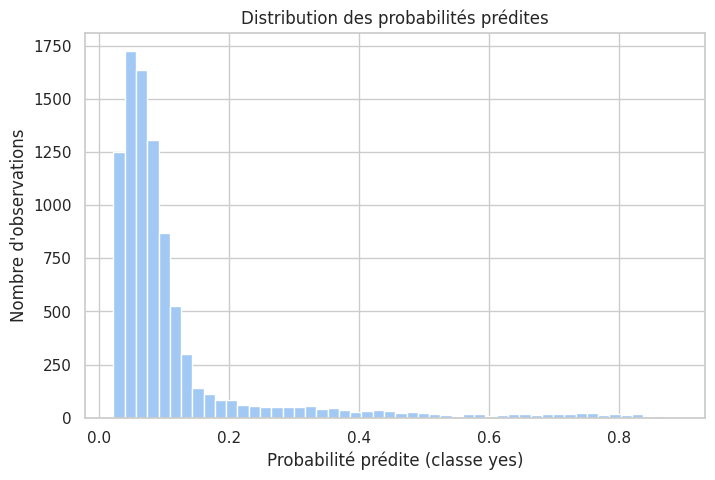

In [22]:
# Probabilités pour la classe positive (y = 1)
X_test = stratified_test.drop(columns=["y"])
# Appliquer uniquement le préprocessing
X_test = preprocessor.fit_transform(X_test)

y_proba = grad_clf.predict_proba(X_test)[:, 1]
y_proba



plt.figure(figsize=(8,5))
plt.hist(y_proba, bins=50)
plt.xlabel("Probabilité prédite (classe yes)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution des probabilités prédites")
plt.show()

